In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_friedman1
import matplotlib.pyplot as plt

import sys

sys.path.append("../..")

In [11]:
from src.models.kernel_regression import KernelRegression
from src.conformal_prediction.ustable_cp import UStableConformalPredictor
from src.conformal_prediction.utils import interval_length

## Example of run
### Sample dataset

In [12]:
sample_size = 500
sample_size_p1 = sample_size + 1

input_points, output_points = make_friedman1(sample_size_p1)
output_points = output_points.reshape(-1, 1)

input_points = StandardScaler().fit_transform(input_points)
output_points = StandardScaler().fit_transform(output_points)

train_input_points = input_points[:-1, :].reshape(sample_size, input_points.shape[1])
train_output_points = output_points[:-1, :].reshape(sample_size, output_points.shape[1])
test_input_point = input_points[-1, :].reshape(1, -1)
test_output_point = output_points[-1, :].reshape(1, -1)

### Instantiate prediction region

In [13]:
loss_name = "log_cosh"
loss_params = {"alpha": 1.0}

# loss_name = "pseudo_huber"
# loss_params = {"alpha": 1.}

# loss_name = "smoothed_pinball"
# loss_params = {"alpha":1., "tau":0.5}

In [14]:
predictor = KernelRegression(
    lam=(1 / sample_size) ** (0.33),
    kernel="laplacian",
    loss_name=loss_name,
    loss_params=loss_params,
)

conformal_predictor = conformal_predictor = UStableConformalPredictor(
    predictor, non_conformity_name="absolute"
)
region_predictor = conformal_predictor.fit_predict(
    train_input_points, train_output_points, test_input_point
)

### Compute prediction region and bounds on thickness

In [15]:
confidence_control_level = 0.1
prediction_region = region_predictor(confidence_control_level)

In [31]:
prediction_region

[{'upper': [array([-1.66981429]),array([1.61528875])],
  'lower': [array([-1.6077442]),array([1.55321866])]}]

In [16]:
empirical_thickness_bound = interval_length(
    prediction_region[0]["upper"] - prediction_region[0]["lower"]
)[0]
theoretical_thickness_bound = conformal_predictor.thickness_upper_bound(
    train_input_points, test_input_point
)[0]

In [32]:
print(empirical_thickness_bound)
print(theoretical_thickness_bound)

0.12414017765327223
0.12414017765327175


## Bench
### Utils

In [18]:
def sample_data(sample_size):
    sample_size_p1 = sample_size + 1

    input_points, output_points = make_friedman1(sample_size_p1)
    output_points = output_points.reshape(-1, 1)

    input_points = StandardScaler().fit_transform(input_points)
    output_points = StandardScaler().fit_transform(output_points)

    train_input_points = input_points[:-1, :].reshape(
        sample_size, input_points.shape[1]
    )
    train_output_points = output_points[:-1, :].reshape(
        sample_size, output_points.shape[1]
    )
    test_input_point = input_points[-1, :].reshape(1, -1)
    test_output_point = output_points[-1, :].reshape(1, -1)

    return train_input_points, train_output_points, test_input_point, test_output_point

In [ ]:
def run(sample_sizes, loss_name, loss_params):
    empirical_thickness_bounds = []
    theoretical_thickness_bounds = []

    for sample_size in sample_sizes:
        train_input_points, train_output_points, test_input_point, test_output_point = (
            sample_data(sample_size)
        )
        predictor = KernelRegression(
            lam=(1 / sample_size) ** (0.33),
            kernel="laplacian",
            loss_name=loss_name,
            loss_params=loss_params,
        )

        conformal_predictor = UStableConformalPredictor(
            predictor, non_conformity_name="absolute"
        )
        region_predictor = conformal_predictor.fit_predict(
            train_input_points, train_output_points, test_input_point
        )

        prediction_region = region_predictor(confidence_control_level)
        empirical_thickness_bound = interval_length(
            prediction_region[0]["upper"] - prediction_region[0]["lower"]
        )[0]
        empirical_thickness_bounds.append(empirical_thickness_bound)

        theoretical_thickness_bound = conformal_predictor.thickness_upper_bound(
            train_input_points, test_input_point
        )[0]
        theoretical_thickness_bounds.append(theoretical_thickness_bound)

    return empirical_thickness_bounds, theoretical_thickness_bounds

In [20]:
def set_style():
    plt.rcParams["text.usetex"] = True
    font = {"family": "normal", "weight": "bold", "size": 22}
    plt.rc("font", **font)

In [21]:
def estimate_rate(x, y):
    mask = np.logical_not(np.logical_or(x == 0, y == 0))
    return (
        (np.log(x[mask]) * np.log(y[mask])).mean()
        - np.log(x[mask]).mean() * np.log(y[mask]).mean()
    ) / ((np.log(x[mask]) ** 2).mean() - (np.log(x[mask]).mean()) ** 2)

In [22]:
def display(sample_sizes, empirical_thickness_bounds, theoretical_thickness_bounds):
    set_style()

    estimated_empirical_rate = estimate_rate(
        sample_sizes, np.array(empirical_thickness_bounds)
    )
    estimated_theoretical_rate = estimate_rate(
        sample_sizes, np.array(theoretical_thickness_bounds)
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(
        sample_sizes,
        empirical_thickness_bounds,
        label=r"$\Delta^{(0)}$, Estimated slope: "
        + "{:.2f}".format(estimated_empirical_rate),
        linestyle="solid",
        color="blue",
        marker="s",
        linewidth=2,
    )
    ax.plot(
        sample_sizes,
        theoretical_thickness_bounds,
        label=r"$Eq.(14)$, Estimated slope: "
        + "{:.2f}".format(estimated_theoretical_rate),
        linestyle="dashed",
        color="red",
        marker="o",
        linewidth=5,
    )

    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid(True)
    ax.legend()
    ax.set_xlabel(r"Sample size $n$")
    ax.set_ylabel(r"Upper bound on the Thickness")
    ax.set_title("Evolution of upper bounds on the Thickness")

    return fig

### Params

In [23]:
loss_name = "log_cosh"
loss_params = {"alpha": 1.0}

# loss_name = "pseudo_huber"
# loss_params = {"alpha": 1.}

# loss_name = "smoothed_pinball"
# loss_params = {"alpha":1., "tau":0.5}


sample_size_min = 128
# sample_size_max = 1024
sample_size_max = 512
step_number = 15
sample_sizes = np.int64(
    np.exp2(
        np.linspace(np.log2(sample_size_min), np.log2(sample_size_max), step_number)
    )
)

confidence_control_level = 0.1

### Run

In [26]:
empirical_thickness_bounds, theoretical_thickness_bounds = run(
    sample_sizes, loss_name, loss_params
)

### Display

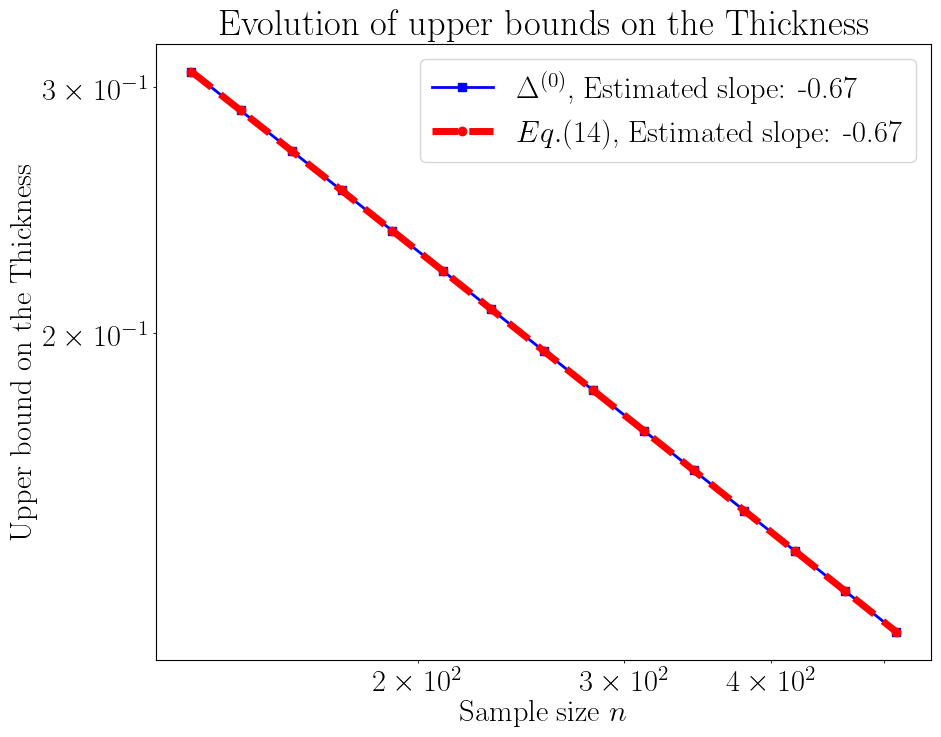

In [27]:
_ = display(sample_sizes, empirical_thickness_bounds, theoretical_thickness_bounds)

### Save

In [ ]:
result = {
    "conformal_predictor": "ustable_cp",
    "loss_name": loss_name,
    "loss_params": loss_params,
    "sample_sizes": sample_sizes,
    "empirical_thickness_bounds": empirical_thickness_bounds,
    "theoretical_thickness_bounds": theoretical_thickness_bounds,
}
result_path = "results/" + "ustable_cp" + "_" + loss_name + ".npy"
np.save(result_path, result)

### Display from save

In [29]:
result_path = "results/" + "ustable_cp" + "_" + loss_name + ".npy"
result_loaded = np.load(result_path, allow_pickle=True).item()

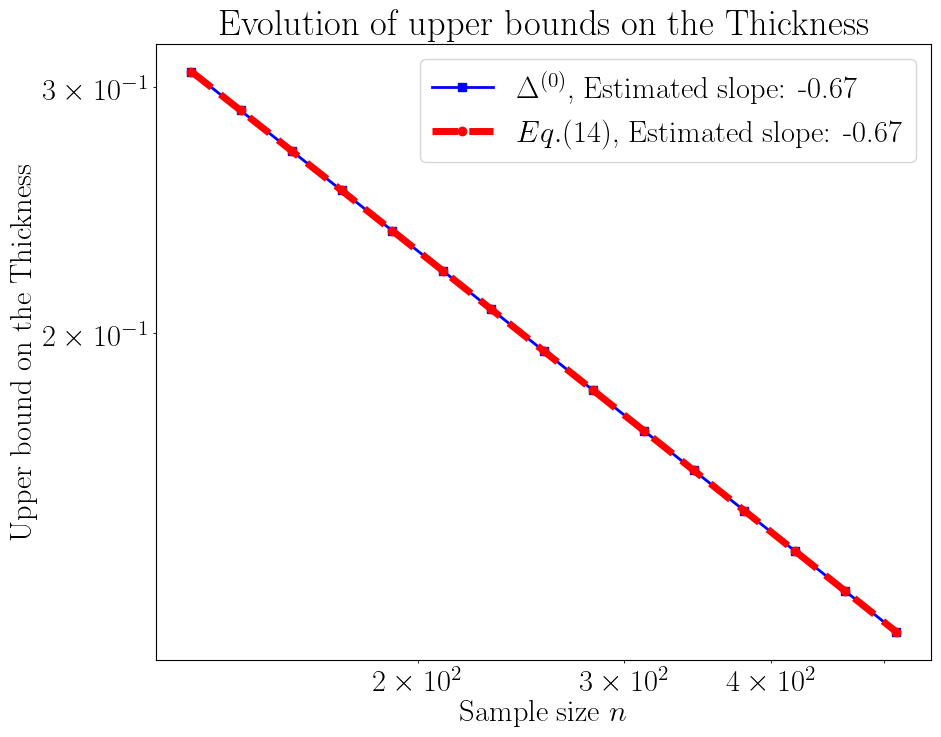

In [30]:
_ = display(
    result_loaded["sample_sizes"],
    result_loaded["empirical_thickness_bounds"],
    result_loaded["theoretical_thickness_bounds"],
)